# Ancestral node repertoires

Three reconstructed nodes: the common ancestor of the human OR repertoire and the
two class ancestors that descend from it.

Ligands are called by density fill (`../../scripts/calibration.py`), not by a chosen
cut; on the ASR matrix it falls at 0.8875. Repertoire sizes are relative — read them
node against node.

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


## Repertoire sizes and overlap

In [2]:
sizes = pd.DataFrame({
    "node": list(anc.per_node_cut),
    "probability_cut": [anc.per_node_cut[n] for n in anc.per_node_cut],
    "n_ligands": [int(anc.node_presence[n].sum()) for n in anc.per_node_cut],
})
print(sizes.to_string(index=False))

overlap = pd.Series({k: len(v) for k, v in anc.sets.items()})
print("\n" + overlap.to_string())
save_table(sizes, "01_node_sizes")

           node  probability_cut  n_ligands
common_ancestor         0.887473         21
class1_ancestor         0.887473         21
class2_ancestor         0.887473          8

common           21
class1           21
class2            8
shared_all        2
class1_gains     17
class2_gains      1
class1_losses    17
class2_losses    14


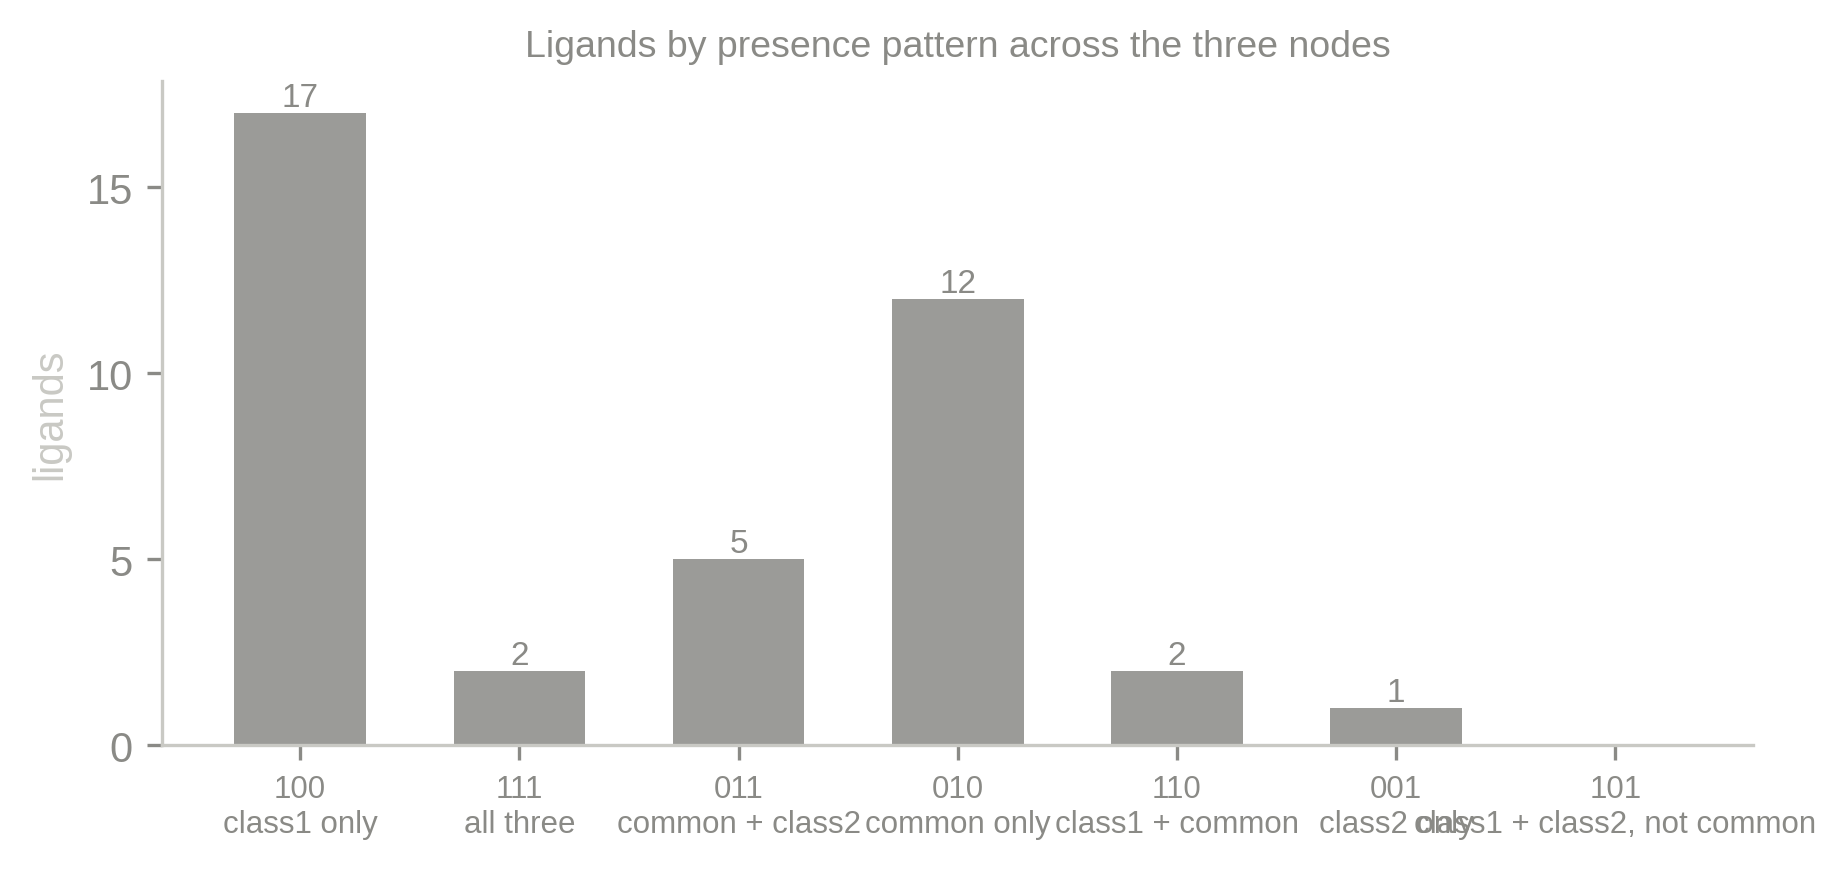

In [3]:
counts = [len(anc.pattern_sets[p]) for p in PATTERN_ORDER]

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1]))
bars = ax.bar(range(len(PATTERN_ORDER)), counts, color="#8a8a86", alpha=0.85, width=0.6)
for i, (p, c) in enumerate(zip(PATTERN_ORDER, counts)):
    if c: ax.text(i, c, str(c), ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(PATTERN_ORDER)))
ax.set_xticklabels([f"{p}\n{PATTERN_LABELS[p]}" for p in PATTERN_ORDER], fontsize=7.5)
ax.set_ylabel("ligands")
ax.set_title("Ligands by presence pattern across the three nodes", fontsize=9)
plt.tight_layout(); save_fig(fig, "01_pattern_counts"); plt.show()

## Gains and losses along each edge

Relative to the common ancestor.

            edge  retained  lost  gained
common -> class1         4    17      17
common -> class2         7    14       1


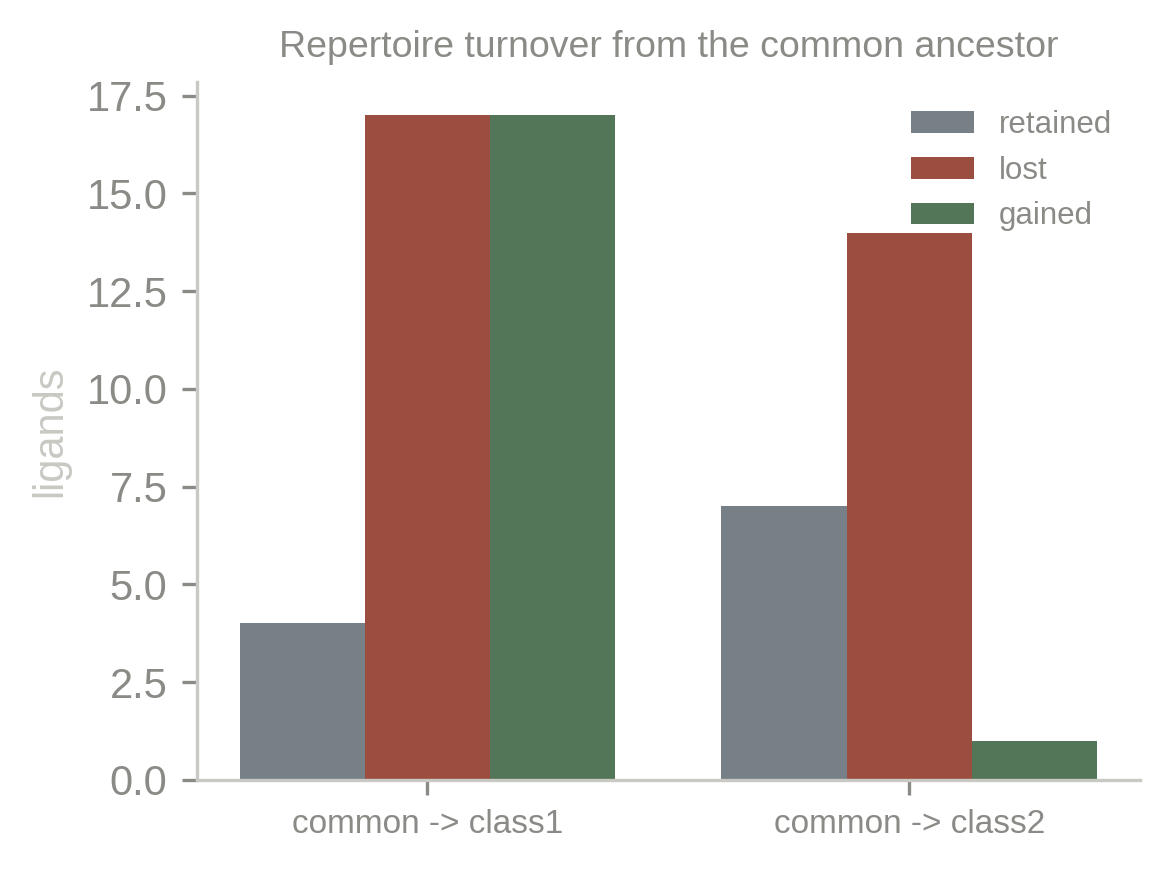


Repertoire sizes differ between nodes here, so gains and losses are free to
be asymmetric — unlike a rank call, which would force them to balance.


In [4]:
edges = pd.DataFrame({
    "edge": ["common -> class1", "common -> class2"],
    "retained": [len(anc.sets["common"] & anc.sets["class1"]),
                 len(anc.sets["common"] & anc.sets["class2"])],
    "lost":     [len(anc.sets["class1_losses"]), len(anc.sets["class2_losses"])],
    "gained":   [len(anc.sets["class1_gains"]),  len(anc.sets["class2_gains"])],
})
print(edges.to_string(index=False))
save_table(edges, "01_repertoire_turnover")

fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(2); w = 0.26
for i, (col, colr) in enumerate([("retained", "#5F6A72"), ("lost", "#8A2F1D"), ("gained", "#355E3B")]):
    ax.bar(x + (i - 1) * w, edges[col], w, label=col, color=colr, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(edges["edge"], fontsize=8)
ax.set_ylabel("ligands"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Repertoire turnover from the common ancestor", fontsize=9)
plt.tight_layout(); save_fig(fig, "01_repertoire_turnover"); plt.show()

print("\nRepertoire sizes differ between nodes here, so gains and losses are free to")
print("be asymmetric — unlike a rank call, which would force them to balance.")

## Chemistry of each node's ligand set

In [5]:
chem = descriptors(anc.all_smiles).merge(functional_groups(anc.all_smiles), on="SMILES")
FG_COLS = list(FG_SMARTS)
chem.head()

,SMILES,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(CCCC(=O)O)CCCBr,2.8065,37.30,223.110,1,1,1,0,0,0,0,0,0,0,0,0,0,0
1,C(CCCCC(=O)O)CCCCBr,3.5867,37.30,251.164,1,1,1,0,0,0,0,0,0,0,0,0,0,0
2,C(CCCCCBr)CCCCC(=O)O,3.9768,37.30,265.191,1,1,1,0,0,0,0,0,0,0,0,0,0,0
3,C(CCCCCC(=O)O)CCCCCBr,4.3669,37.30,279.218,1,1,1,0,0,0,0,0,0,0,0,0,0,0
4,C/C=C/C(=O)C1=C(C=CCC1(C)C)C,3.4342,17.07,190.286,0,1,0,0,0,1,0,0,0,0,0,0,0,1


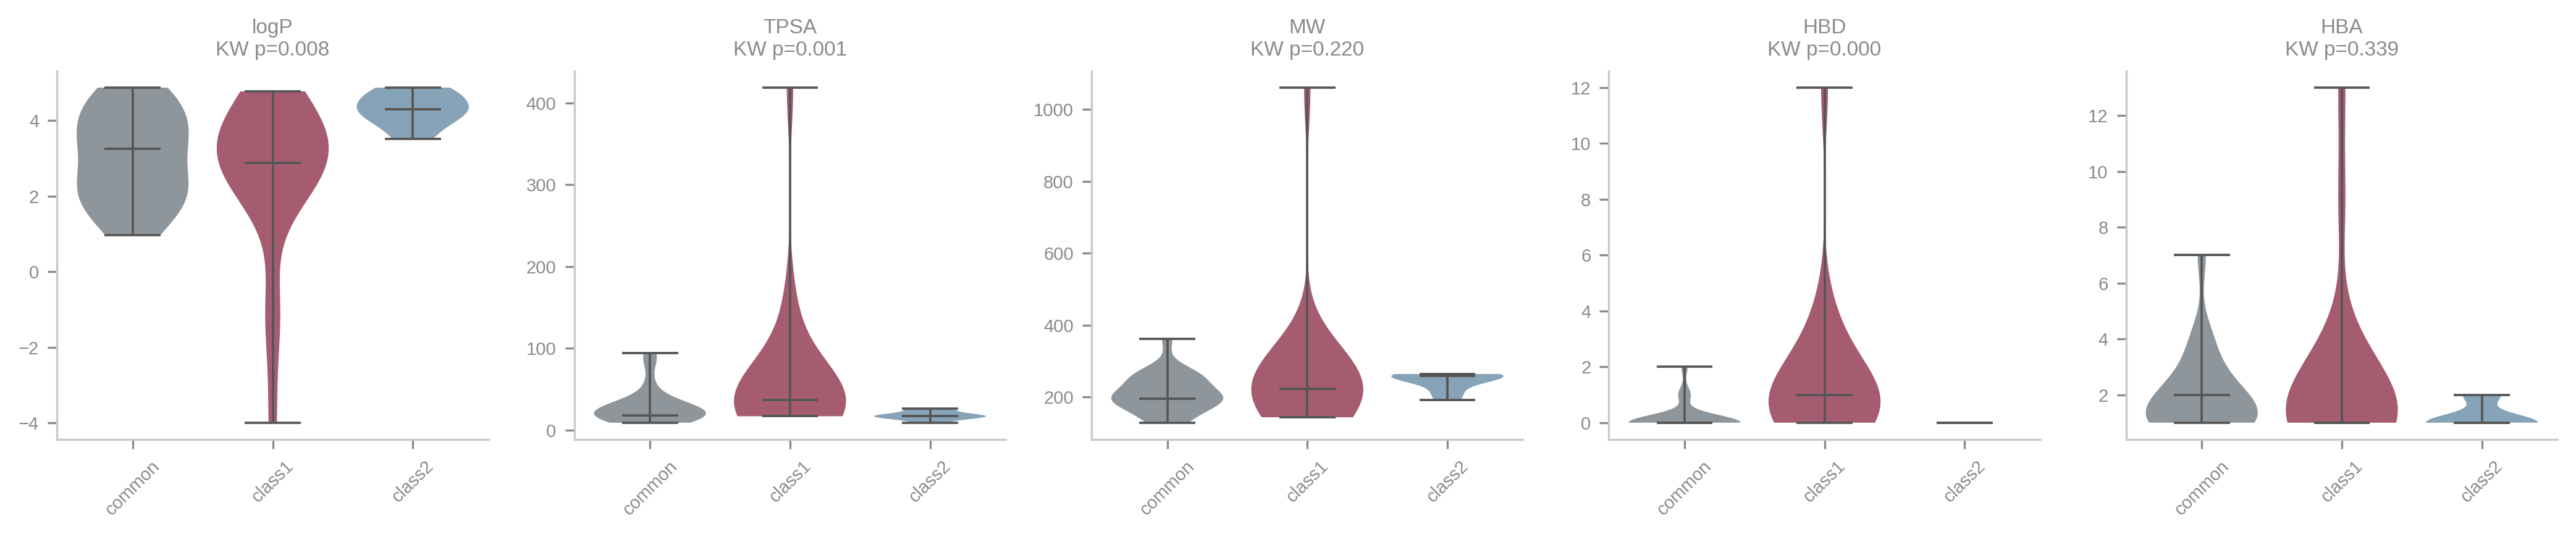

In [6]:
node_chem = []
for node in anc.per_node_cut:
    smi = set(anc.node_presence.loc[anc.node_presence[node] == 1, "SMILES"])
    sub = chem[chem.SMILES.isin(smi)]
    node_chem.append(sub.assign(node=node))
node_chem = pd.concat(node_chem)

fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.7, FIGSIZE[1]))
for ax, desc in zip(axes, DESCRIPTORS):
    data = [node_chem.loc[node_chem.node == n, desc].dropna().values for n in anc.per_node_cut]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for pc, n in zip(parts["bodies"], anc.per_node_cut):
        pc.set_facecolor(NODE_COL[n]); pc.set_alpha(0.7); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    h, p = kruskal(*data)
    ax.set_title(f"{desc}\nKW p={p:.3f}", fontsize=8)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["common", "class1", "class2"], fontsize=7, rotation=45)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "01_node_descriptors"); plt.show()

## Functional groups per node

The common ancestor is the baseline: it shows whether a group was inherited or acquired.

                 common  class1  class2  fisher_p_class1_vs_class2
carboxylic_acid    0.00   47.62     0.0                       0.03
alkene            57.14   33.33    25.0                       1.00
aromatic_ring     61.90   33.33    50.0                       0.43
ether             52.38   23.81    37.5                       0.65
phenol             4.76   14.29     0.0                       0.54
ketone            42.86   14.29    62.5                       0.02
alcohol            4.76   14.29     0.0                       0.54
amine              0.00   14.29     0.0                       0.54
aldehyde           4.76    9.52     0.0                       1.00
ester             28.57    9.52    25.0                       0.30
amide              4.76    4.76     0.0                       1.00
nitrile            0.00    0.00     0.0                       1.00


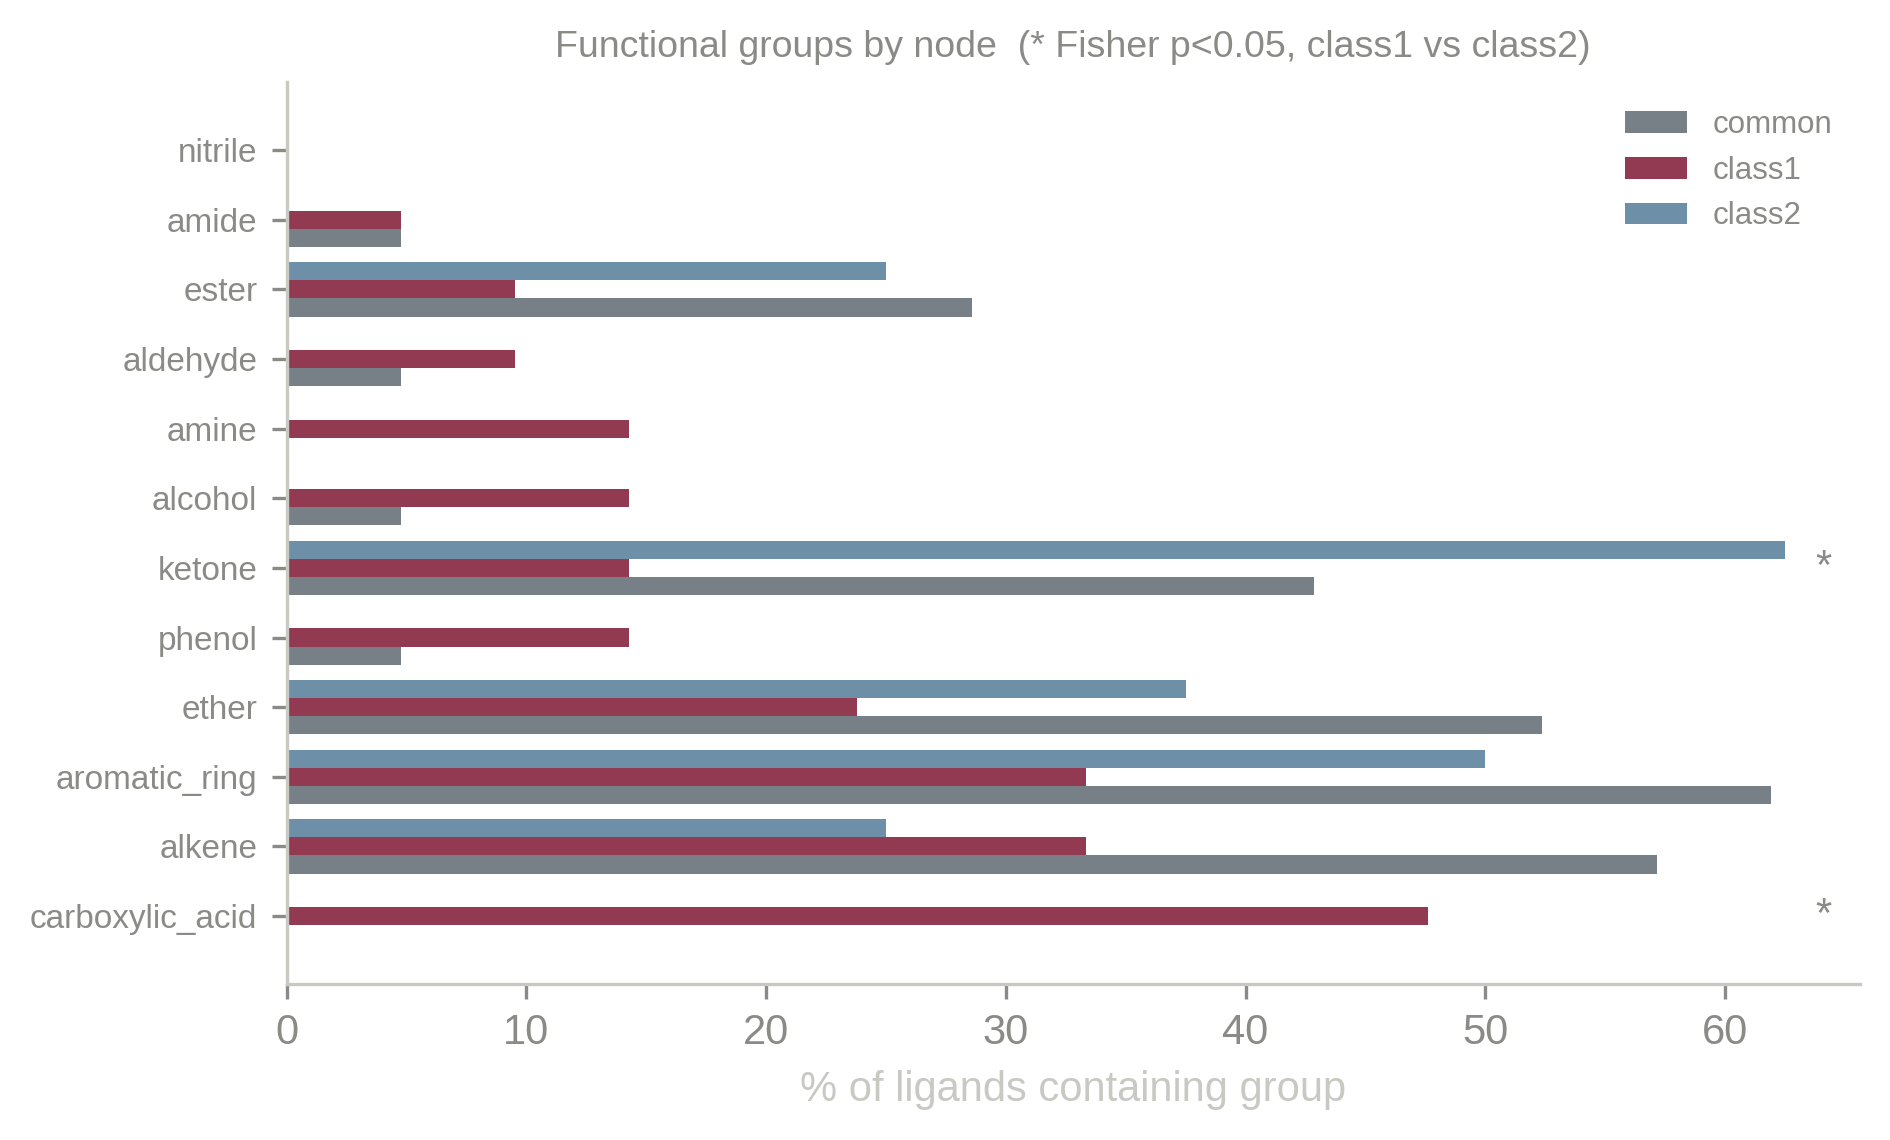

In [7]:
set_of = {"common": anc.sets["common"], "class1": anc.sets["class1"], "class2": anc.sets["class2"]}
prev = pd.DataFrame({g: chem[chem.SMILES.isin(v)][FG_COLS].mean() * 100 for g, v in set_of.items()})
pv = []
for fg in FG_COLS:
    a = chem[chem.SMILES.isin(set_of["class1"])][fg]
    b = chem[chem.SMILES.isin(set_of["class2"])][fg]
    pv.append(fisher_exact([[int(a.sum()), len(a) - int(a.sum())],
                            [int(b.sum()), len(b) - int(b.sum())]])[1])
prev["fisher_p_class1_vs_class2"] = pv
prev = prev.sort_values("class1", ascending=False)
print(prev.round(2).to_string())
save_table(prev.reset_index().rename(columns={"index": "functional_group"}),
           "01_functional_groups")

show = prev.drop(columns="fisher_p_class1_vs_class2")
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.3))
y = np.arange(len(show)); w = 0.26
for i, (g, c) in enumerate(zip(set_of, [COMMON_COL, CLASS1_COL, CLASS2_COL])):
    ax.barh(y + (i - 1) * w, show[g], w, color=c, alpha=0.85, label=g)
for yi, pval in zip(y, prev["fisher_p_class1_vs_class2"]):
    if pval < 0.05: ax.text(show.values.max() * 1.02, yi, "*", va="center", fontsize=10, color="#8a8a86")
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=8)
ax.set_xlabel("% of ligands containing group"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Functional groups by node  (* Fisher p<0.05, class1 vs class2)", fontsize=9)
plt.tight_layout(); save_fig(fig, "01_node_functional_groups"); plt.show()

## Odour descriptors per node

In [8]:
tags = odor_tags()
tag_map = dict(zip(tags.SMILES, tags.tags))

rows = []
for node in anc.per_node_cut:
    smi = set(anc.node_presence.loc[anc.node_presence[node] == 1, "SMILES"])
    flat = [t for s in smi for t in tag_map.get(s, [])]
    for t, c in pd.Series(flat).value_counts().head(8).items():
        rows.append({"node": node, "tag": t, "n": c})
top_tags = pd.DataFrame(rows)
wide = top_tags.pivot(index="tag", columns="node", values="n").fillna(0).astype(int)
print(wide.to_string())
save_table(wide.reset_index(), "01_top_odour_tags")

node     class1_ancestor  class2_ancestor  common_ancestor
tag                                                       
amber                  0                3                0
cheesy                 4                0                0
citrus                 3                0                0
dry                    0                2                0
fatty                  4                0                0
floral                 0                2                9
fresh                  2                0                0
fruity                 0                3                9
musk                   0                4                4
powdery                0                2                3
rose                   0                0                4
spicy                  2                0                4
sweet                  4                6               17
waxy                   4                0                0
woody                  2                2               